In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
train = pd.read_csv("../data/train-test.csv")
validation = pd.read_csv("../data/validation.csv")

In [4]:
train.shape

(48000, 14)

In [5]:
validation.shape

(12000, 13)

In [6]:
train.columns.tolist()

['load_id',
 'pickup',
 'delivery',
 'pickup_lat',
 'pickup_lon',
 'delivery_lat',
 'delivery_lon',
 'distance',
 'equipment',
 'weight',
 'date',
 'market_index',
 'quote_signal',
 'posted_rate']

In [7]:
train.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,1/1/2025,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,1/1/2025,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,1/1/2025,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,1/1/2025,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,1/1/2025,0.98480,2.56300,1380.28


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [9]:
set(train.columns) - set(validation.columns)

{'posted_rate'}

In [10]:
train.isnull().sum().sort_values(ascending=False)

market_index    374
weight          300
delivery          0
pickup_lat        0
load_id           0
pickup            0
delivery_lat      0
pickup_lon        0
distance          0
delivery_lon      0
equipment         0
date              0
quote_signal      0
posted_rate       0
dtype: int64

In [11]:
(train.isnull().mean()*100).sort_values(ascending=False)

market_index    0.779167
weight          0.625000
delivery        0.000000
pickup_lat      0.000000
load_id         0.000000
pickup          0.000000
delivery_lat    0.000000
pickup_lon      0.000000
distance        0.000000
delivery_lon    0.000000
equipment       0.000000
date            0.000000
quote_signal    0.000000
posted_rate     0.000000
dtype: float64

In [12]:
train.duplicated().sum()

np.int64(0)

In [13]:
duplicate_rows = train[train.duplicated()]
duplicate_rows.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate


In [14]:
train.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [16]:
(train["weight"] < 0).sum()

np.int64(292)

In [17]:
(train["distance"] < 0).sum()

np.int64(0)

In [18]:
(train["posted_rate"] <= 0).sum()

np.int64(0)

In [19]:
(train["posted_rate"] <= 0).any()

np.False_

In [20]:
train["date"] = pd.to_datetime(train["date"])
(train["date"].min(), train["date"].max())

(Timestamp('2025-01-01 00:00:00'), Timestamp('2025-10-31 00:00:00'))

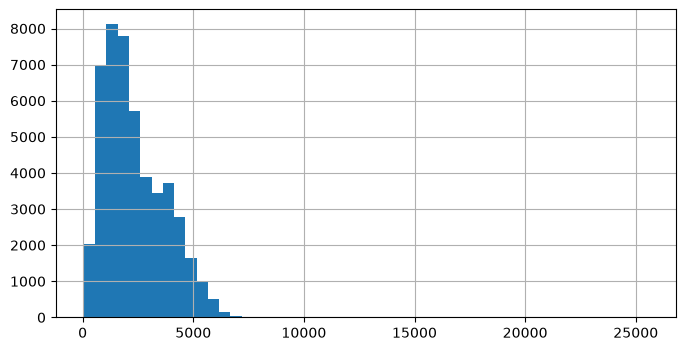

In [21]:
plt.figure(figsize=(8,4))

train["posted_rate"].hist(bins=50)

plt.show()

In [23]:
train["pickup"].nunique()

64

In [22]:
train["delivery"].nunique()

64

In [24]:
train["equipment"].value_counts()

equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

In [25]:
numeric_cols = train.select_dtypes(include=np.number)
numeric_cols.corr()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
pickup_lat,1.000000,0.559208,-0.008283,-0.006143,-0.077742,0.001898,-0.001735,-0.004181,-0.090873
pickup_lon,0.559208,1.000000,-0.008609,-0.012231,-0.273411,0.006603,0.001432,0.013659,-0.255058
delivery_lat,-0.008283,-0.008609,1.000000,0.557083,-0.080646,-0.004243,-0.002587,-0.002708,-0.091970
delivery_lon,-0.006143,-0.012231,0.557083,1.000000,-0.275657,-0.001144,-0.008487,0.011437,-0.257086
distance,-0.077742,-0.273411,-0.080646,-0.275657,1.000000,0.002544,-0.002181,-0.057244,0.908519
weight,0.001898,0.006603,-0.004243,-0.001144,0.002544,1.000000,-0.001331,0.008159,0.034840
market_index,-0.001735,0.001432,-0.002587,-0.008487,-0.002181,-0.001331,1.000000,-0.067827,0.034165
quote_signal,-0.004181,0.013659,-0.002708,0.011437,-0.057244,0.008159,-0.067827,1.000000,-0.039858
posted_rate,-0.090873,-0.255058,-0.091970,-0.257086,0.908519,0.034840,0.034165,-0.039858,1.000000
